# Practice 5 — pandas + NumPy
Work through each task in order. Try to solve it yourself before looking anything up!

In [1]:
import pandas as pd
import numpy as np

---
## Level 1 — Basics

### Task 1: Create & Convert
1. Create a DataFrame with 5 rows representing products. Columns: `name`, `category` (Electronics, Clothing, or Food), `price` (float), `units_sold` (integer)
2. Extract the `price` column as a NumPy array using `.to_numpy()`
3. Use NumPy to calculate the **total revenue** (`price * units_sold`) and add it back as a new column `revenue`

In [ ]:
# 1. Create the DataFrame
data = {
    'name':       ['apple',"bose",'cloth','desktop','eyewear'],   # 5 product names
    'category':   ['Food','Electronics','Clothing','Electronics','Clothing'],   # Electronics, Clothing, or Food
    'price':      [20.0,12.0,3.5,45.0,6.3],   # 5 prices (floats)
    'units_sold': [10,30,20,34,5],   # 5 unit counts (integers)
}

products = pd.DataFrame(data)

# 2. Extract price as a NumPy array
p = products['price'].to_numpy()

# 3. Calculate revenue using NumPy and add as a column
products['revenue'] = p*products['units_sold']

products

,name,category,price,units_sold,revenue
0,apple,Food,20.0,10,200.0
1,bose,Electronics,12.0,30,360.0
2,cloth,Clothing,3.5,20,70.0
3,desktop,Electronics,45.0,34,1530.0
4,eyewear,Clothing,6.3,5,31.5


### Task 2: Inspect & Describe
Run the cell below to load a dataset, then:
1. Use `.info()` and `.describe()` to explore it
2. Extract the `total_bill` column as a NumPy array
3. Use NumPy to find the **mean**, **median**, and **standard deviation** of `total_bill`

**Question:** How do the NumPy results compare to what `.describe()` showed?

In [3]:
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv'
tips = pd.read_csv(url)
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [9]:
# 1. Explore with .info() and .describe()
tips.info()
tips.describe()

# 2. Extract total_bill as a NumPy array

t = tips['total_bill'].to_numpy()
# 3. Mean, median, std using NumPy
np.mean(t)
np.median(t)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


np.float64(17.795)

In [26]:
np.median(tips['total_bill'])

np.float64(17.795)

### Task 3: Duplicates & Unique Values
A DataFrame with duplicate rows has been created for you.
1. Find duplicate rows using `.duplicated()`
2. Remove duplicates using `.drop_duplicates()`
3. Use `np.unique()` on the `city` column to get unique cities and a count of how many times each appears (hint: `np.unique(..., return_counts=True)`)

In [24]:
# Starter data — don't change this
visits = pd.DataFrame({
    'user':   ['Alice', 'Bob', 'Alice', 'Carol', 'Bob', 'Alice'],
    'city':   ['NYC', 'LA', 'NYC', 'Chicago', 'LA', 'NYC'],
    'visits': [3, 5, 3, 2, 5, 3],
})

# 1. Find duplicate rows

visits.duplicated()
# 2. Remove duplicates
visits.drop_duplicates()

# 3. Unique cities and counts using np.unique
#np.unique(visits['city'].to_numpy(),return_counts=True)
np.unique(visits['city'],return_counts=True)

(array(['Chicago', 'LA', 'NYC'], dtype=object), array([1, 2, 3]))

---
## Level 2 — Transformations

### Task 4: Bin Data with `pd.cut()`
A DataFrame of exam scores has been created for you.
1. Use `pd.cut()` to add a `grade` column with these bins:
   - 0–59 → `'F'`, 60–69 → `'D'`, 70–79 → `'C'`, 80–89 → `'B'`, 90–100 → `'A'`
2. Use `np.percentile()` to find the 25th, 50th, and 75th percentiles of the scores

In [19]:
# Starter data — don't change this
np.random.seed(1)
exams = pd.DataFrame({
    'student': [f'Student_{i}' for i in range(1, 11)],
    'score':   np.random.randint(45, 100, size=10),
})

# 1. Add grade column using pd.cut()
exams['grade']=pd.cut(exams['score'],
                      bins = [0,59,69,79,89,100],
                      labels= ['F','D','C','B','A'])

# 2. 25th, 50th, 75th percentiles using np.percentile()

np.percentile(exams['score'].to_numpy(),q=[25,50,75])


array([53.25, 56.5 , 60.75])

In [22]:
exams[['score']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   score   10 non-null     int64
dtypes: int64(1)
memory usage: 208.0 bytes


### Task 5: Replace & Clip Values
A DataFrame of sensor readings has been created for you.
1. Use `.map()` to add a `status` column — map `sensor_id` values: `1 → 'Active'`, `2 → 'Idle'`, `3 → 'Offline'`
2. Use `np.clip()` to cap the `reading` values between 0 and 100 (remove outliers), and store the result in a new column `reading_clipped`
3. Use `np.where()` to add an `alert` column — `True` if `reading_clipped` > 80, `False` otherwise

In [35]:
# Starter data — don't change this
np.random.seed(3)
sensors = pd.DataFrame({
    'sensor_id': np.random.choice([1, 2, 3], size=8),
    'reading':   np.random.uniform(-20, 130, size=8).round(1),
})

# 1. Map sensor_id to status
sensors['status'] = sensors['sensor_id'].map({1:'Active',2:'Idle',3:'Offline'})

# 2. Clip readings to 0-100
sensors['reading_clipped'] = np.clip(sensors['reading'],0,100)

# 3. Add alert column using np.where()
sensors['alert'] = np.where(sensors['reading_clipped']>80, True, False)
sensors['alert2'] = sensors['reading_clipped'].apply(lambda x: True if x>80 else False)

sensors

,sensor_id,reading,status,reading_clipped,alert,alert2
0,3,45.6,Offline,45.6,False,False
1,1,-17.2,Active,0.0,False,False
2,2,-13.9,Idle,0.0,False,False
3,1,17.2,Active,17.2,False,False
4,1,-6.0,Active,0.0,False,False
5,1,84.2,Active,84.2,True,True
6,2,1.8,Idle,1.8,False,False
7,2,48.0,Idle,48.0,False,False


In [31]:
np.where(sensors['reading_clipped']>80)

(array([5]),)

### Task 6: Missing Data + NumPy
A DataFrame with missing values has been created for you.
1. Show how many nulls are in each column using `.isnull().sum()`
2. Extract the `temperature` column as a NumPy array — notice that `np.mean()` returns `nan` when there are missing values
3. Fix it using `np.nanmean()`, `np.nanmedian()`, `np.nanstd()` (these ignore NaN)
4. Fill missing `temperature` values in the DataFrame with the `np.nanmedian()`

In [49]:
# Starter data — don't change this
weather = pd.DataFrame({
    'day':         ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
    'temperature': [22.1, np.nan, 19.8, np.nan, 24.3, 21.0, np.nan],
    'humidity':    [55, 60, np.nan, 58, 62, np.nan, 57],
})

# 1. Count nulls per column
weather.isnull().sum()

# 2. Extract temperature as NumPy array and try np.mean()
np.mean(weather['temperature'])
tn = weather['temperature'].to_numpy()

# 3. Use np.nanmean(), np.nanmedian(), np.nanstd()
np.nanmean(tn)
np.nanmedian(tn)
np.nanstd(tn)

# 4. Fill missing temperature with the nanmedian
weather['temperature'] = weather['temperature'].fillna(np.nanmedian(tn))
weather

,day,temperature,humidity
0,Mon,22.10,55.0
1,Tue,21.55,60.0
2,Wed,19.80,NaN
3,Thu,21.55,58.0
4,Fri,24.30,62.0
5,Sat,21.00,NaN
6,Sun,21.55,57.0


---
## Level 3 — Aggregation

### Task 7: GroupBy + NumPy Aggregations
Using the `sales` DataFrame below:
1. Group by `region` and find the **total**, **mean**, and **max** revenue using `.agg()`
2. Extract the revenue values as a NumPy array and compute the **cumulative sum** using `np.cumsum()`
3. Use `np.argsort()` on the revenue array to get the indices that would sort it — then use those indices to sort the `rep` column

In [ ]:
# Starter data — don't change this
sales = pd.DataFrame({
    'rep':     ['Alice', 'Bob', 'Carol', 'Dave', 'Emma'],
    'region':  ['North', 'South', 'North', 'East', 'South'],
    'revenue': [4200, 3150, 5800, 4700, 3900],
})

# 1. GroupBy region with total, mean, max
sales.groupby('region')['revenue'].agg(['sum','mean','max'])

# 2. Cumulative sum of revenue using np.cumsum()
rn = sales['revenue'].to_numpy()
np.cumsum(rn)

# 3. Sort reps by revenue using np.argsort()

aa = np.argsort(rn)
#sales['rep'][aa]
sales['rep'].to_numpy()[aa]

array(['Bob', 'Emma', 'Alice', 'Dave', 'Carol'], dtype=object)

### Task 8: Rolling Average
A time series DataFrame has been created for you.
1. Add a `rolling_avg` column with a **7-day rolling mean** using `.rolling(7).mean()`
2. Extract both `value` and `rolling_avg` as NumPy arrays
3. Use `np.corrcoef()` to check how correlated the rolling average is with the original values
4. Plot both columns on the same chart (call `.plot()` on the DataFrame with both columns selected)

<Axes: xlabel='date'>

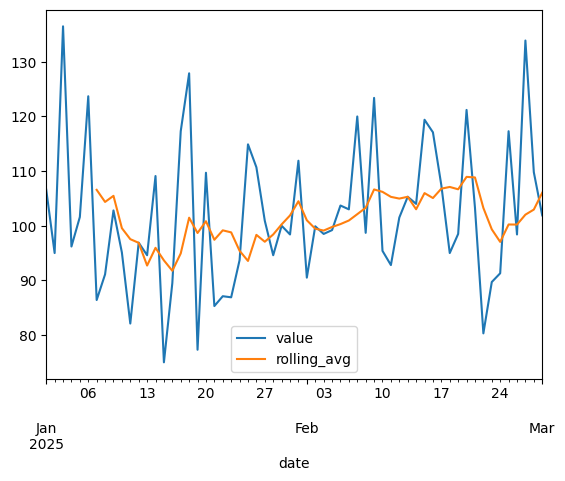

In [66]:
# Starter data — don't change this
np.random.seed(5)
dates = pd.date_range('2025-01-01', periods=60, freq='D')
ts = pd.DataFrame({
    'date':  dates,
    'value': np.random.normal(100, 15, size=60).round(1),
})
ts = ts.set_index('date')

# 1. Add 7-day rolling average column
ts['rolling_avg'] = ts['value'].rolling(7).mean()
ts
# 2. Extract both columns as NumPy arrays (use .dropna() first to remove NaN rows)
value_array = ts.dropna()['value'].to_numpy()
ra_array = ts.dropna()['rolling_avg'].to_numpy()




# 3. Correlation between value and rolling_avg

np.corrcoef(value_array, ra_array)
# 4. Plot both columns
ts[['value','rolling_avg']].plot()

### Task 9: Merge + Matrix Math
Three DataFrames are provided. 
1. Merge `students` and `scores` on `student_id`
2. Merge the result with `weights` on `subject`
3. Use NumPy to compute each student's **weighted average score**: multiply the score by the weight for each subject, sum them up per student (hint: `np.dot()`)

In [ ]:
# Starter data — don't change this
students = pd.DataFrame({
    'student_id': [1, 2, 3],
    'name':       ['Alice', 'Bob', 'Carol'],
})

scores = pd.DataFrame({
    'student_id': [1, 1, 1, 2, 2, 2, 3, 3, 3],
    'subject':    ['Math', 'English', 'Science'] * 3,
    'score':      [90, 85, 88, 72, 91, 78, 85, 79, 92],
})

weights = pd.DataFrame({
    'subject': ['Math', 'English', 'Science'],
    'weight':  [0.4, 0.3, 0.3],   # weights sum to 1.0
})

# 1. Merge students and scores
s = students.merge(scores,how = "inner", on = 'student_id')

# 2. Merge result with weights
ss = s.merge(weights, how = "inner", on = 'subject')

# 3. Compute weighted average score per student using np.dot()
ss['ws'] = ss['score'].to_numpy() * ss['weight'].to_numpy()


ss.groupby('student_id').apply(lambda g: np.dot(g['score'], g['weight']))


/var/folders/3r/5sttq01d46zg8zxyw17j5nbw0000gn/T/ipykernel_82360/705359379.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ss.groupby('student_id').apply(lambda g: np.dot(g['score'], g['weight']))


student_id
1    87.9
2    79.5
3    85.3
dtype: float64

---
## Level 4 — Real-world

### Task 10: Full Pipeline
Load the penguins dataset and run a full analysis combining pandas and NumPy:
1. Drop rows with any missing values using `.dropna()`
2. Use `.str.contains()` to filter to only Adelie or Chinstrap penguins
3. For each species, use `.groupby()` + `.agg()` to get the mean and std of `bill_length_mm` and `flipper_length_mm`
4. Extract `bill_length_mm` and `flipper_length_mm` as NumPy arrays and compute their **correlation** using `np.corrcoef()`
5. Normalize `bill_length_mm` to a 0–1 range using min-max normalization and add it as a new column `bill_length_norm`

In [108]:
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv'
penguins = pd.read_csv(url)
print(penguins.shape)
# 1. Drop rows with missing values
penguins = penguins.dropna()
penguins.shape
# 2. Filter to Adelie or Chinstrap using .str.contains()
penguins = penguins[penguins['species'].str.contains('Adelie|Chinstrap')]

# 3. Mean and std of bill_length_mm and flipper_length_mm per species
penguins.groupby('species')[['bill_length_mm','flipper_length_mm']].agg(['mean','std'])

# 4. Correlation between bill_length_mm and flipper_length_mm
b = penguins['bill_depth_mm'].to_numpy()
f = penguins['flipper_length_mm'].to_numpy()
np.corrcoef(b,f)

# 5. Normalize bill_length_mm to 0-1 range
b = penguins['bill_length_mm']
bn = (b-b.min())/(b.max()-b.min())
penguins['bill_length_norm'] = bn

(344, 7)


In [109]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,bill_length_norm
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE,0.270270
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE,0.285714
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE,0.316602
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE,0.177606
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE,0.277992
...,...,...,...,...,...,...,...,...
215,Chinstrap,Dream,55.8,19.8,207.0,4000.0,MALE,0.915058
216,Chinstrap,Dream,43.5,18.1,202.0,3400.0,FEMALE,0.440154
217,Chinstrap,Dream,49.6,18.2,193.0,3775.0,MALE,0.675676
218,Chinstrap,Dream,50.8,19.0,210.0,4100.0,MALE,0.722008
